In [32]:
import torch.nn as nn
import torch.nn.functional as F
import torch
import torchvision.datasets.cifar as cf
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import PIL.Image as Image
from torch.utils.data import DataLoader,Dataset
from tqdm import tqdm
from torch.utils.data import random_split
from torch.optim.lr_scheduler import StepLR
import numpy as np
import wandb
import pandas as pd
import os
import torchvision.models as models

# os.mkdir("./trained_models")

In [33]:
def heatmap_corner(cx, cy, h, w, sigma):
    x = torch.arange(0, w, dtype=torch.float32)
    y = torch.arange(0, h, dtype=torch.float32)
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    gaussian_hmap = torch.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))
    return gaussian_hmap

In [34]:
!nvidia-smi

Sun May  3 09:35:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             31W /   70W |    1313MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [35]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
N_CHANNELS = 3



In [36]:
class DatasetChecko(Dataset):
    def __init__(self,data_path,gt_path):
        super().__init__()
        self.data_path = data_path
        self.gt = gt_path
        self.filepaths = []
        self.labels = []

        data_dir = os.listdir(self.data_path)

        gt = pd.read_csv(self.gt)
        for idx, fname in enumerate(data_dir):
            if fname.lower().endswith(('.png','.jpg')):
                gtrow = gt.loc[gt["filename"] == fname]
                if len(gtrow) > 0:
                    self.filepaths.append(os.path.join(self.data_path,fname))
                    gt_string = gtrow['corners'].values[0]
                    gt_coords = [float(x) for x in gt_string.split()]
                    gt_coords.append(gtrow['check_corners'].values[0])
                    self.labels.append(gt_coords)

    def __len__(self,):
        return len(self.filepaths)

    def __getitem__(self,idx):
        image_name = self.filepaths[idx]
        label = self.labels[idx]
        image = Image.open(image_name)
        orig_w, orig_h = image.size
        image = image.resize((IMAGE_WIDTH, IMAGE_HEIGHT))
        image_tensor = transform(image)
        label = self.labels[idx].copy() #do nto alter saved list

        HM_H, HM_W = 56, 56
        heatmaps = []
        for i in range(0,8,2):
            cx = label[i] / orig_w * HM_W
            cy = label[i+1] / orig_h * HM_H
            heatmaps.append(heatmap_corner(cx,cy,HM_H,HM_W,sigma=2))

        heatmaps = torch.stack(heatmaps)

        label = torch.tensor([label[8]], dtype=torch.float32)

        return image_tensor,heatmaps, label

In [37]:
dataset_train = DatasetChecko("/content/drive/MyDrive/tag_boundary_detection_training_data/flash_images","/content/drive/MyDrive/tag_boundary_detection_training_data/train_corners.csv")
dataset_val = DatasetChecko("/content/drive/MyDrive/tag_boundary_detection_training_data/flash_images","/content/drive/MyDrive/tag_boundary_detection_training_data/val_corners.csv")


# train_ratio = 0.8
# val_ratio = 0.2
# dataset_train, dataset_val = random_split(dataset,[train_ratio, val_ratio])
# # dataset_val = DatasetChecko("flash_images/flash_images","val_corners.csv")

In [38]:
def BatchLoader(dataset,batch_size,train_flag):
    dataloader = DataLoader(dataset=dataset,batch_size=batch_size,shuffle=True if train_flag else False, drop_last=True)
    return dataloader

In [39]:
class HeatmapCorner(nn.Module):
    def __init__(self,):
        super().__init__()
        resnet = models.resnet18(weights="DEFAULT")
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512,256,kernel_size=4,stride=2,padding=1), #Hout​=(Hin​−1)×stride−2×padding+kernel_size (just opp of conv)
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256,128,kernel_size=4,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128,4,kernel_size=4,stride=2,padding=1),
        )

    def forward(self,x):
        features = self.encoder(x)
        heatmaps = self.decoder(features)

        return heatmaps



In [40]:
class HeatmapCornerlabel(nn.Module):
    def __init__(self,):
        super().__init__()
        resnet = models.resnet18(weights="DEFAULT")
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512,256,kernel_size=4,stride=2,padding=1), #Hout​=(Hin​−1)×stride−2×padding+kernel_size (just opp of conv)
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256,128,kernel_size=4,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128,4,kernel_size=4,stride=2,padding=1),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conf_head = nn.Linear(512,1)


    def forward(self,x):
        features = self.encoder(x)
        heatmaps = self.decoder(features)
        pooled = self.pool(features)
        pooled = pooled.view(pooled.size(0), -1)
        conf_logits = self.conf_head(pooled)

        return heatmaps, conf_logits



In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS =4
EPS = float("inf")
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
WEIGHT_DECAY = 0.0001
MODEL_DIR = "./trained_models"

w1 = 1
w2 = 1

model = HeatmapCornerlabel().to(device=device)
optimizer = torch.optim.Adam(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
# scheduler = StepLR(optimizer,step_size=int(np.floor(EPOCHS/10)),gamma=0.1)

train_loader = BatchLoader(dataset=dataset_train,batch_size=BATCH_SIZE,train_flag=True)
valid_loader = BatchLoader(dataset=dataset_val,batch_size=BATCH_SIZE,train_flag=False)

In [42]:
for name, param in model.named_parameters():
    print(f"{name:40s} | requires_grad={param.requires_grad}")


encoder.0.weight                         | requires_grad=True
encoder.1.weight                         | requires_grad=True
encoder.1.bias                           | requires_grad=True
encoder.4.0.conv1.weight                 | requires_grad=True
encoder.4.0.bn1.weight                   | requires_grad=True
encoder.4.0.bn1.bias                     | requires_grad=True
encoder.4.0.conv2.weight                 | requires_grad=True
encoder.4.0.bn2.weight                   | requires_grad=True
encoder.4.0.bn2.bias                     | requires_grad=True
encoder.4.1.conv1.weight                 | requires_grad=True
encoder.4.1.bn1.weight                   | requires_grad=True
encoder.4.1.bn1.bias                     | requires_grad=True
encoder.4.1.conv2.weight                 | requires_grad=True
encoder.4.1.bn2.weight                   | requires_grad=True
encoder.4.1.bn2.bias                     | requires_grad=True
encoder.5.0.conv1.weight                 | requires_grad=True
encoder.

In [43]:
bce_loss = nn.BCEWithLogitsLoss()
def combined_loss(pred_heatmaps, pred_conf, gt_heatmaps, gt_conf):
    hm_loss = F.mse_loss(pred_heatmaps, gt_heatmaps)
    conf_loss = bce_loss(pred_conf, gt_conf)
    return hm_loss + conf_loss

In [44]:
def train_loop(train_loader,optimizer,device):
    model.train()
    total_train_loss = 0
    for batch_idx, (batch_images,batch_heatmaps,batch_labels) in enumerate(tqdm(train_loader)):
        batch_images = batch_images.to(device)
        batch_heatmaps = batch_heatmaps.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        pred_heatmaps, pred_labels =  model(batch_images)
        # loss = heatmap_loss(pred_heatmaps,batch_heatmaps)
        loss = combined_loss(pred_heatmaps,pred_labels,batch_heatmaps,batch_labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss/len(train_loader)
    return avg_train_loss

def val_loop(val_loader,device):
    model.eval()
    total_val_loss = 0
    for batch_idx, (batch_images,batch_heatmaps,batch_labels) in enumerate(tqdm(val_loader)):
        batch_images = batch_images.to(device)
        batch_heatmaps = batch_heatmaps.to(device)
        batch_labels = batch_labels.to(device)
        with torch.no_grad():
            pred_heatmaps, pred_labels =  model(batch_images)
            # loss = heatmap_loss(pred_heatmaps,batch_heatmaps)
            loss = combined_loss(pred_heatmaps,pred_labels,batch_heatmaps,batch_labels)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss/len(val_loader)
    return avg_val_loss

train_loss_list = []
valid_loss_list = []

# try:
for epoch in range(EPOCHS):
    train_avg_loss = train_loop(train_loader,optimizer,device)
    val_avg_loss = val_loop(valid_loader,device)
    # scheduler.step()
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_avg_loss:.4f} | Val Loss: {val_avg_loss:.4f}")
    checkpoint = {'epoch' : epoch, 'model_state_dict' : model.state_dict(), 'optimizer_state_dict' : optimizer.state_dict(), 'loss' : train_avg_loss, }
    if val_avg_loss < EPS:
        EPS = val_avg_loss
        torch.save(checkpoint, os.path.join(MODEL_DIR,"Resnet18.pt"))
    torch.save(checkpoint,os.path.join(MODEL_DIR,"last.pt"))
    train_loss_list.append(train_avg_loss)
    valid_loss_list.append(val_avg_loss)

# except KeyboardInterrupt:
#     print("\nTraining stopped by user.")
# except Exception as e:
#     print(f"\n[!] Training crashed with error: {e}")


100%|██████████| 50/50 [00:55<00:00,  1.12s/it]


Epoch [1/4] | Train Loss: 0.0655 | Val Loss: 0.0049


100%|██████████| 50/50 [00:55<00:00,  1.12s/it]


Epoch [2/4] | Train Loss: 0.0040 | Val Loss: 0.0035


100%|██████████| 50/50 [00:57<00:00,  1.14s/it]


Epoch [3/4] | Train Loss: 0.0020 | Val Loss: 0.0013


100%|██████████| 50/50 [00:55<00:00,  1.12s/it]


Epoch [4/4] | Train Loss: 0.0007 | Val Loss: 0.0007


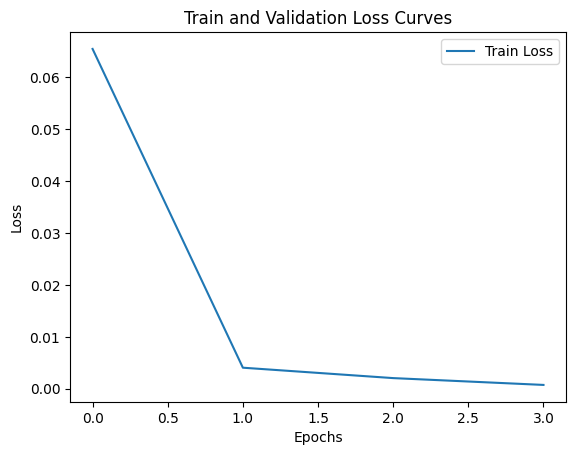

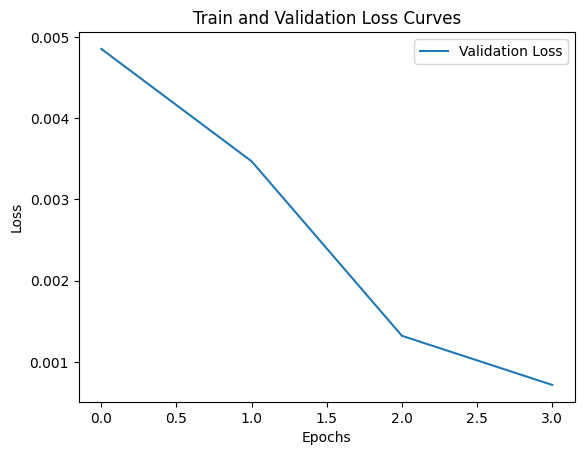

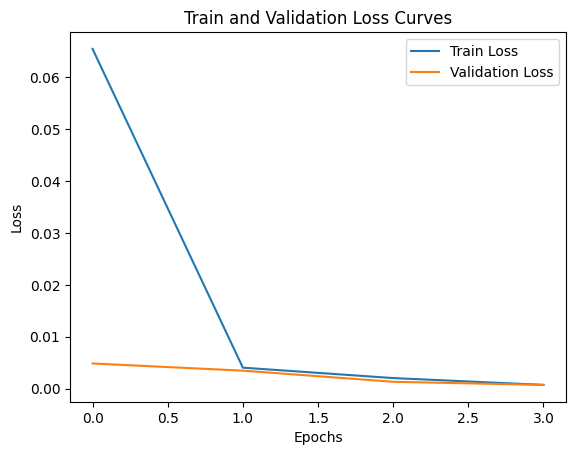

In [45]:
if len(train_loss_list) > 0 and len(valid_loss_list) > 0:
    plt.plot(range(EPOCHS), train_loss_list, label="Train Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train and Validation Loss Curves")
    plt.legend()
    plt.show()


    plt.plot(range(EPOCHS), valid_loss_list, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train and Validation Loss Curves")
    plt.legend()
    plt.show()

    #plot loss curves

    plt.plot(range(EPOCHS), train_loss_list, label="Train Loss")
    plt.plot(range(EPOCHS), valid_loss_list, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train and Validation Loss Curves")
    plt.legend()
    plt.show()

In [46]:
CONF_THRESHOLD = 0.5
PEAK_THRESHOLD = 0.1

def checkmodel_heatmap(image_path, model, model_path=None):
    if model_path is not None:
        state_dict = torch.load(model_path, weights_only=True)
        model.load_state_dict(state_dict['model_state_dict'])
    model.eval()

    image = Image.open(image_path).convert("RGB")
    orig_w, orig_h = image.size
    image_tensor = transform(image.resize((IMAGE_WIDTH, IMAGE_HEIGHT))).unsqueeze(0).to(device)

    HM_H, HM_W = 56, 56
    with torch.no_grad():
        output = model(image_tensor)

    if isinstance(output, tuple):
        pred_heatmaps, conf_logits = output
        conf_score = torch.sigmoid(conf_logits).item()
    else:
        pred_heatmaps = output
        conf_score = None

    pred_heatmaps = pred_heatmaps.squeeze(0).cpu()
    peak_vals = [pred_heatmaps[i].max().item() for i in range(4)]
    avg_peak = sum(peak_vals) / 4

    tag_present = (conf_score >= CONF_THRESHOLD) if conf_score is not None else (avg_peak >= PEAK_THRESHOLD)

    if not tag_present:
        print(f"No tag detected — conf={conf_score:.3f}" if conf_score is not None else f"No tag detected — avg_peak={avg_peak:.3f}")
        return None

    corners = []
    for i in range(4):
        max_idx = pred_heatmaps[i].argmax()
        cx = (max_idx % HM_W).float() / HM_W * orig_w
        cy = (max_idx // HM_W).float() / HM_H * orig_h
        corners.append((cx.item(), cy.item()))

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for i in range(4):
        axes.flat[i].imshow(pred_heatmaps[i].numpy(), cmap='hot', interpolation='nearest')
        axes.flat[i].set_title(f"Heatmap C{i+1} (peak={peak_vals[i]:.3f})")
        axes.flat[i].axis('off')
    axes.flat[4].axis('off')

    ax = axes[1][2]
    ax.imshow(image)
    xs, ys = zip(*(corners + [corners[0]]))
    ax.plot(xs, ys, 'g-', linewidth=2)
    for i, (cx, cy) in enumerate(corners):
        ax.plot(cx, cy, 'ro', markersize=8)
        ax.text(cx + 5, cy - 5, f'C{i+1}', color='yellow', fontsize=10, fontweight='bold')
    ax.set_title(f"Predicted Corners (conf={conf_score:.3f})" if conf_score is not None else f"Predicted Corners (avg_peak={avg_peak:.3f})")
    ax.axis('off')

    plt.tight_layout()
    plt.show()

    for i, (cx, cy) in enumerate(corners):
        print(f"  C{i+1}: ({cx:.1f}, {cy:.1f})  peak={peak_vals[i]:.4f}")

    return corners

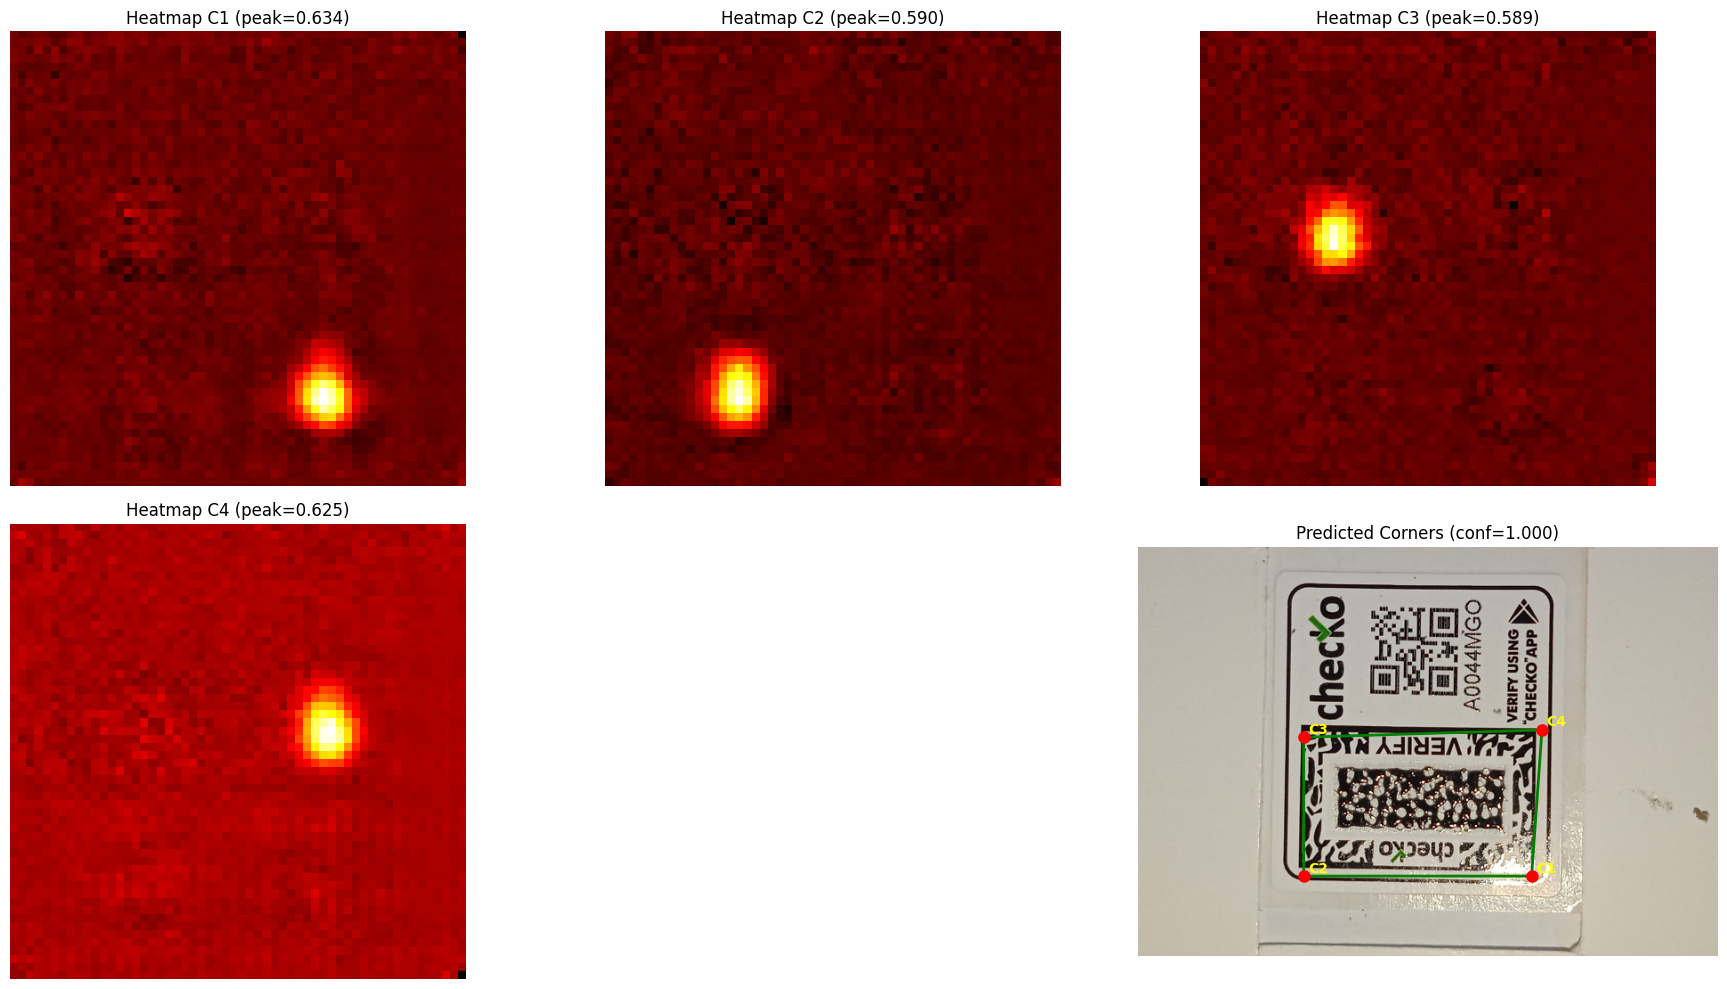

  C1: (442.4, 369.6)  peak=0.6345
  C2: (186.3, 369.6)  peak=0.5900
  C3: (186.3, 213.6)  peak=0.5889
  C4: (454.1, 205.4)  peak=0.6246


[(442.4285583496094, 369.6428527832031),
 (186.2857208251953, 369.6428527832031),
 (186.2857208251953, 213.57142639160156),
 (454.0714416503906, 205.35714721679688)]

In [50]:
image_name = "/content/drive/MyDrive/tag_boundary_detection_training_data/flash_images/A0044MGO_Flash0_A0044MGOfullhd_1632980533838_2.0.7.png"
checkmodel_heatmap(image_name, model=model,model_path="/content/trained_models/last.pt")


In [49]:
!realpath ./trained_models/last.pt


/content/trained_models/last.pt
